# **Duelo Entre Modelos**

## **Pontos Fortes da Árvore de Decisão**

**Interpretação Simples:** As árvores de decisão são fáceis de entender e interpretar. A lógica por trás das decisões é transparente e pode ser facilmente visualizada.

**Capacidade de Capturar Interações Não Lineares:** Ao contrário de modelos lineares, as árvores de decisão conseguem capturar relações complexas entre as variáveis.

**Necessidade Mínima de Pré-processamento:** Elas costumam funcionar bem mesmo sem uma etapa extensa de normalização ou padronização.

**Versatilidade:** Podem ser utilizadas tanto em problemas de classificação quanto de regressão.

## **Pontos Fracos da Árvore de Decisão**

**Propensão ao Overfitting:** Árvores muito profundas podem se ajustar demais aos dados de treino e perder capacidade de generalização.

**Sensibilidade a Pequenas Variações nos Dados:** Mudanças discretas na base podem gerar árvores bem diferentes.

**Desempenho em Bases Ruidosas:** Quando há muitas variáveis irrelevantes ou ruído, o modelo pode perder consistência.

Vamos agora apresentar nosso segundo campeão, o **Random Forest**. Esse modelo pode ser visto como uma evolução da Árvore de Decisão, pois combina várias árvores treinadas em subconjuntos diferentes dos dados e dos atributos. Ao reunir as previsões dessas árvores, o Random Forest reduz a variância de uma única árvore e tende a entregar resultados mais robustos e estáveis em problemas de classificação.

## **Pontos Fortes do Random Forest**

**Maior Robustez:** A combinação de várias árvores reduz o risco de decisões instáveis causadas por uma única amostra.

**Boa Capacidade de Generalização:** Em muitos casos, o Random Forest sofre menos com overfitting do que uma árvore isolada.

**Capacidade de Capturar Relações Não Lineares:** Assim como as árvores, consegue modelar padrões complexos entre as variáveis.

**Versatilidade:** Pode ser usado tanto para classificação quanto para regressão, mantendo bom desempenho em diferentes contextos.

## **Pontos Fracos do Random Forest**

**Menor Interpretabilidade:** Como o modelo combina várias árvores, entender exatamente o motivo de cada previsão se torna mais difícil.

**Maior Custo Computacional:** O treinamento costuma ser mais pesado do que em uma única árvore, especialmente com muitos estimadores.

**Mais Hiperparâmetros para Ajustar:** O desempenho depende de escolhas como número de árvores, profundidade máxima e quantidade de atributos por divisão.

# **Arena do duelo**

Para nosso duelo entre a **Árvore de Decisão** e o **Random Forest**, utilizaremos a famosa base de dados do **Titanic**. Essa base é amplamente usada em estudos de machine learning porque traz um problema de classificação binária bastante claro: prever se um passageiro sobreviveu ou não ao naufrágio com base em características como classe, idade, tarifa, sexo e porto de embarque.

### **Variáveis que merecem atenção**

**Pclass:** Classe do bilhete do passageiro. É uma variável ordinal que representa a classe socioeconômica.

**SibSp:** Número de irmãos ou cônjuges a bordo.

**Parch:** Número de pais ou filhos a bordo.

**Fare:** Valor pago pela passagem.

**Embarked:** Porto de embarque do passageiro.

### **Objetivo da análise**

Nosso objetivo é comparar o comportamento dos modelos em três etapas: pouco pré-processamento, aplicação de padronização e balanceamento, e ajuste fino de hiperparâmetros.

### **Conjunto de teste**

A base de teste não possui a variável resposta. Depois de gerar as previsões, essas saídas podem ser submetidas para avaliação da pontuação obtida pelos modelos.

### **Estratégia do duelo**

No primeiro round, vamos comparar os modelos com o mínimo de pré-processamento.

No segundo, aplicaremos balanceamento e padronização para medir o impacto dessas etapas.

Por fim, ajustaremos hiperparâmetros para verificar qual modelo responde melhor ao tuning.

### **O que esperamos observar**

A Árvore de Decisão tende a reagir rápido mesmo com pouca preparação dos dados, mas pode sofrer mais com overfitting.

Já o Random Forest tende a ser mais robusto, especialmente quando o problema exige maior estabilidade e generalização.

Com esse contexto definido, podemos iniciar os duelos e avaliar qual modelo entrega o melhor equilíbrio entre simplicidade, desempenho e capacidade de generalização.

In [ ]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Bibliotecas para os modelos de machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Bibliotecas para métricas de avaliação
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


class: Classe do bilhete do passageiro (1 = 1ª classe, 2 = 2ª classe, 3 = 3ª classe). Esta coluna é uma variável ordinal que indica a classe socioeconômica do passageiro.

SibSp: Número de irmãos/cônjuges a bordo. Esta coluna indica quantos irmãos e/ou cônjuges a pessoa tinha no navio.

Parch: Número de pais/filhos a bordo. Esta coluna indica quantos pais e/ou filhos a pessoa tinha no navio.

Fare: Tarifa paga pelo bilhete. Esta coluna indica o valor da passagem que o passageiro pagou para embarcar no Titanic.


Embarked: Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton). Esta coluna indica o porto onde o passageiro embarcou no navio.

In [ ]:
# Preenchendo valores nulos em Age com a média
train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
test_df['Age'].fillna(test_df['Age'].mean(), inplace=True)
test_df['Fare'].fillna(test_df['Fare'].mean(), inplace=True)

In [ ]:
# 1. Para a variável 'Sex', podemos usar Label Encoding, pois há apenas duas categorias
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
# 2. Para a variável 'Embarked', podemos usar One-Hot Encoding, pois há mais de duas categorias
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked')

In [ ]:
# 3. Para a variável 'Cabin', podemos apenas criar uma nova variável indicando se a cabine é conhecida ou não
train_df['Cabin_known'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin_known'] = test_df['Cabin'].notna().astype(int)

# Agora podemos descartar a coluna 'Cabin' original
train_df = train_df.drop(columns=['Cabin'])
test_df_teste = test_df.drop(columns=['Cabin'])

In [ ]:
train_df = train_df.drop(columns=['Name','Ticket'])

In [ ]:
variaveis = ['Sex', 'Cabin_known','Fare','Pclass']

In [ ]:
# Separando as variáveis dependentes (Y) e independentes (X) no conjunto de treino
X = train_df[variaveis]
y = train_df['Survived']

X_test = test_df[variaveis]

Vale notar que a base de teste não possui a variável resposta. Por isso, depois de gerar as previsões, precisamos submetê-las para descobrir a pontuação final do modelo.

# **DUELO 1**

**Com o minimo de pré processamento**

### **ARVORE DE DECISÃO:**

In [ ]:
# Criando o modelo da Arvore
arvore_duelo1 = DecisionTreeClassifier(random_state=42)

In [ ]:
# Treinando o modelo de Arvore com os dados de treino
arvore_duelo1.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Fazendo previsões com o modelo treinado nos dados de treino
Y_arvore_duelo1 = arvore_duelo1.predict(X)

In [ ]:
relatorio = classification_report(y, Y_arvore_duelo1)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       549
           1       0.92      0.84      0.88       342

    accuracy                           0.91       891
   macro avg       0.91      0.90      0.91       891
weighted avg       0.91      0.91      0.91       891



### **RANDOM FOREST:**

In [ ]:
# Criando o modelo da floresta
rf_duelo1 = RandomForestClassifier(random_state=42)

In [ ]:
# Treinando o modelo da floresta com os dados de treino
rf_duelo1.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
# Fazendo previsões com o modelo treinado nos dados de treino
Y_floresta_duelo1 = rf_duelo1.predict(X)

In [ ]:
relatorio = classification_report(y, Y_floresta_duelo1)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       549
           1       0.91      0.86      0.88       342

    accuracy                           0.91       891
   macro avg       0.91      0.90      0.91       891
weighted avg       0.91      0.91      0.91       891



Os resultados deste primeiro duelo mostram um comportamento esperado: os dois modelos conseguem bom desempenho na base de treino, mas o **Random Forest** tende a entregar previsões mais estáveis, enquanto a **Árvore de Decisão** pode parecer muito forte por se ajustar demais aos dados vistos. Só nos próximos rounds será possível avaliar com mais clareza qual modelo generaliza melhor.

# **DUELO 2**

**Padronizando e Balanceando**

Mesmo que o **Random Forest** costume depender menos de pré-processamento, vale testar padronização e balanceamento para medir o quanto essas etapas ainda ajudam no desempenho. Essa comparação é importante porque modelos diferentes reagem de formas diferentes à mesma preparação dos dados.

In [ ]:
# Balanceando os dados com SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X, y)

In [ ]:
# Padronizando os dados
scaler = StandardScaler()
# Ajustando e transformando os dados de treino balanceados
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Tamanho do conjunto de treino balanceado: {X_train_balanced_scaled.shape[0]}")
print(f"Tamanho do conjunto de teste: {X_test_scaled.shape[0]}")

Tamanho do conjunto de treino balanceado: 1098
Tamanho do conjunto de teste: 418


In [ ]:
print("Distribuição das classes antes do balanceamento:")
print(y.value_counts())

Distribuição das classes antes do balanceamento:
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
print("\nDistribuição das classes depois do balanceamento:")
print(Y_train_balanced.value_counts())


Distribuição das classes depois do balanceamento:
Survived
0    549
1    549
Name: count, dtype: int64


### **ARVORE DE DECISÃO:**

In [ ]:
arvore_duelo2 = DecisionTreeClassifier(random_state=42)

In [ ]:
arvore_duelo2.fit(X_train_balanced_scaled, Y_train_balanced)

DecisionTreeClassifier(random_state=42)

In [ ]:
Y_arvore_duelo2 = arvore_duelo2.predict(X_train_balanced_scaled)

In [ ]:
relatorio = classification_report(Y_train_balanced, Y_arvore_duelo2)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       549
           1       0.94      0.89      0.91       549

    accuracy                           0.92      1098
   macro avg       0.92      0.92      0.92      1098
weighted avg       0.92      0.92      0.92      1098



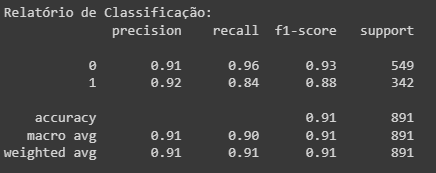

Os resultados melhoraram após a padronização e o balanceamento dos dados. Essas etapas ajudam os modelos a lidar melhor com a distribuição das classes e tornam a comparação mais justa entre as abordagens.

A melhora do **Random Forest** após essas transformações reforça sua capacidade de adaptação. Já a **Árvore de Decisão** pode até se beneficiar, mas continua mais sensível a variações e ao risco de overfitting quando comparada ao conjunto de árvores da floresta.

### **RANDOM FOREST:**

In [ ]:
floresta_duelo2 = RandomForestClassifier(random_state=42)

In [ ]:
floresta_duelo2.fit(X_train_balanced_scaled, Y_train_balanced)

RandomForestClassifier(random_state=42)

In [ ]:
Y_floresta_duelo2 = floresta_duelo2.predict(X_train_balanced_scaled)

In [ ]:
relatorio = classification_report(Y_train_balanced, Y_floresta_duelo2)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       549
           1       0.93      0.90      0.92       549

    accuracy                           0.92      1098
   macro avg       0.92      0.92      0.92      1098
weighted avg       0.92      0.92      0.92      1098



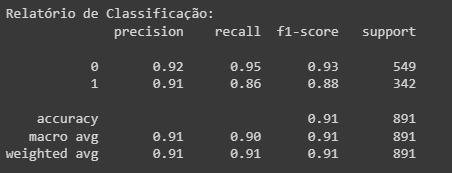

Vemos que o **Random Forest** respondeu muito bem ao pré-processamento, especialmente na identificação da classe 1. Isso mostra que, mesmo sendo naturalmente mais robusto a dados desbalanceados e menos dependente de escala, ele ainda pode ganhar desempenho quando recebe uma preparação mais cuidadosa.

# **DUELO FINAL**

**Tunando os modelos**

Nesta etapa, vamos comparar qual modelo responde melhor ao **ajuste fino de hiperparâmetros**. A expectativa é que o **Random Forest** apresente ganhos mais consistentes por ser um modelo mais flexível, enquanto a **Árvore de Decisão** pode melhorar bastante em pontos específicos, principalmente no controle de complexidade.

### **ARVORE DE DECISÃO:**

#### **Hiperparâmetros para Ajuste**

**criterion:** Define a métrica usada para escolher as divisões da árvore, como `gini` ou `entropy`.

**max_depth:** Controla a profundidade máxima da árvore.

**min_samples_split:** Define o número mínimo de amostras necessário para dividir um nó.

**min_samples_leaf:** Define o número mínimo de amostras permitido em uma folha.

**max_depth: Profundidade Máxima**

O que é: Pense na profundidade como o número de perguntas que a árvore pode fazer até chegar a uma decisão final.

Como funciona: Uma árvore muito profunda aprende muitos detalhes do treino e pode acabar decorando padrões específicos. Uma árvore mais rasa faz menos perguntas e tende a generalizar melhor.

Por que é importante: Ajustar a profundidade ajuda a equilibrar desempenho e controle de overfitting.

**criterion, min_samples_split e min_samples_leaf**

**criterion:** Escolhe como a árvore mede a qualidade de cada divisão.

**min_samples_split:** Impede divisões em nós com poucas observações.

**min_samples_leaf:** Garante que as folhas finais não fiquem pequenas demais.

Juntos, esses hiperparâmetros ajudam a controlar a complexidade do modelo e evitam que a árvore se ajuste demais aos dados de treino.

In [ ]:
arvore_duelo3 = DecisionTreeClassifier(random_state=42)

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],  # Critério de divisão
    'max_depth': [None, 10, 20, 30, 40, 50, 5],  # Profundidade máxima da árvore
    'min_samples_split': [2, 10, 20, 5, 30],  # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 5, 10, 2, 15],  # Número mínimo de amostras em um nó folha
}

In [ ]:
grid_search_arvore = GridSearchCV(arvore_duelo3, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
#Ajustando o Grid Search aos dados de treino
grid_search_arvore.fit(X_train_balanced_scaled, Y_train_balanced)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30, 40, 50, 5],
                         'min_samples_leaf': [1, 5, 10, 2, 15],
                         'min_samples_split': [2, 10, 20, 5, 30]},
             scoring='accuracy')

In [ ]:
# Melhores parâmetros encontrados
best_params_arvore = grid_search_arvore.best_params_
print(f"Melhores parâmetros: {best_params_arvore}")

Melhores parâmetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 20}


In [ ]:
#Melhor modelo
best_arvore_model = grid_search_arvore.best_estimator_
best_arvore_model.fit(X_train_balanced_scaled, Y_train_balanced)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [ ]:
Y_pred_arvore = best_arvore_model.predict(X_train_balanced_scaled)
report_arvore = classification_report(Y_train_balanced, Y_pred_arvore)
print("Relatório de Métricas - Modelo com Grid Search (Árvore de Decisão):\n", report_arvore)

Relatório de Métricas - Modelo com Grid Search (Árvore de Decisão):
               precision    recall  f1-score   support

           0       0.84      0.91      0.88       549
           1       0.90      0.83      0.87       549

    accuracy                           0.87      1098
   macro avg       0.87      0.87      0.87      1098
weighted avg       0.87      0.87      0.87      1098



In [ ]:
Y_pred_tree = best_arvore_model.predict(X_test_scaled)

In [ ]:
Y_pred_tree

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
sub_tree = pd.Series(Y_pred_tree, index=test_df['PassengerId'], name = 'Survived')

In [ ]:
sub_tree.to_csv("submissao_tree.csv" , header=True)

### **RANDOM FOREST:**

#### **Hiperparâmetros para Ajuste**

**n_estimators:** Número de árvores na floresta.

**max_depth:** Profundidade máxima de cada árvore.

**min_samples_split:** Número mínimo de amostras para dividir um nó.

**min_samples_leaf:** Número mínimo de amostras em cada folha.

**max_features:** Quantidade de variáveis consideradas em cada divisão.

**n_estimators: Quantidade de Árvores**

O que é: Representa quantas árvores diferentes vão participar da decisão final da floresta.

Como funciona: Quanto mais árvores, maior tende a ser a estabilidade da previsão. Em contrapartida, o treinamento fica mais pesado.

Por que é importante: Esse parâmetro ajuda a equilibrar robustez e custo computacional.

**max_depth, min_samples_split e min_samples_leaf**

Esses três hiperparâmetros controlam o quanto cada árvore individual pode crescer.

**max_depth:** Limita a profundidade máxima da árvore.

**min_samples_split:** Evita divisões em nós com poucas amostras.

**min_samples_leaf:** Garante folhas com um tamanho mínimo.

Na prática, eles ajudam a evitar árvores exageradamente complexas dentro da floresta.

**max_features: Quantas Variáveis Cada Árvore Observa**

O que é: Define quantas variáveis estarão disponíveis para cada decisão tomada pelas árvores da floresta.

Como funciona: Ao limitar o número de variáveis por divisão, aumentamos a diversidade entre as árvores.

Por que é importante: Essa diversidade é parte central da força do Random Forest, porque reduz a correlação entre as árvores e melhora a generalização do conjunto.

In [ ]:
floresta_duelo3 = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200, 20],  # Número de árvores na floresta
    'max_depth': [None, 10, 20, 30, 5],  # Profundidade máxima de cada árvore
    'min_samples_split': [2, 5, 10],  # Número mínimo de amostras necessárias para dividir um nó
    'min_samples_leaf': [1, 2, 4, 6],  # Número mínimo de amostras necessárias para estar em um nó folha
    'max_features': ['sqrt', 'log2', None]  # Número máximo de recursos considerados para dividir um nó
}

In [ ]:
grid_search_floresta = GridSearchCV(floresta_duelo3, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
# Executando o Randomized Search
grid_search_floresta.fit(X_train_balanced_scaled, Y_train_balanced)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 5],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 20]},
             scoring='accuracy')

In [ ]:
best_params_floresta = grid_search_floresta.best_params_
print(f"Melhores parâmetros: {best_params_floresta}")

Melhores parâmetros: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
best_floresta_model = grid_search_floresta.best_estimator_
best_floresta_model.fit(X_train_balanced_scaled, Y_train_balanced)

RandomForestClassifier(max_depth=10, max_features=None, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [ ]:
Y_pred_arvore = best_floresta_model.predict(X_train_balanced_scaled)
report_arvore = classification_report(Y_train_balanced, Y_pred_arvore)
print("Relatório de Métricas - Modelo com Grid Search (Árvore de Decisão):\n", report_arvore)

Relatório de Métricas - Modelo com Grid Search (Árvore de Decisão):
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       549
           1       0.92      0.87      0.89       549

    accuracy                           0.89      1098
   macro avg       0.90      0.89      0.89      1098
weighted avg       0.90      0.89      0.89      1098



In [ ]:
Y_pred_forest_sub = floresta_duelo2.predict(X_test_scaled)

In [ ]:
Y_pred_forest_sub

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
sub_forest = pd.Series(Y_pred_forest_sub, index=test_df['PassengerId'], name = 'Survived')

In [ ]:
sub_forest.to_csv("sub_forest.csv" , header=True)